In [1]:
import functions as fn
from mastu import HSV
import numpy as np
import sys

In [2]:
plot = True

In [3]:
### load the dictionary
dictFile = '/home/sthoma/tokamak_inversion_routines/Dictionaries/51347_experiment10.txt'
inputDict = fn.loadDict(dictFile)

### unzip the dictionary
shotn = inputDict['shotn']
Rzfile = inputDict['Rzfile']
maskFile = inputDict['maskFile']

### the inputs to select which bits of video, and averaging
I0 = inputDict['I0']
I1 = inputDict['I1']
J0 = inputDict['J0']
J1 = inputDict['J1']
tend = inputDict['tend']
raverage = inputDict['raverage']
taverage = inputDict['taverage']
# T0 = inputDict['T0']
# T1 = inputDict['T1']
T0 = 182
T1 = 183

### for converting to photons and account for vignetting
photons = bool(inputDict['photons'])
# exposureMult = inputDict['exposureMult']
vignette = bool(inputDict['vignette'])

### variables for the inversion, should be approximately constant
saveFile = inputDict['saveFile']
rEnd = 1.525 # inputDict['rEnd']
nrMult = inputDict['nrMult']
sysErr = inputDict['sysErr']
photon = bool(inputDict['photon'])
biasedEdges = bool(inputDict['biasedEdges'])
nFisher = inputDict['nFisher']
regGuess = inputDict['regGuess']
regMin = inputDict['regMin']

### use pedestal fitting or raw Thomson
kindThomson = inputDict['kindThomson']
### R value pedestal fitting works up to
Rprofile0 = inputDict['Rprofile0']

### kind of interpolation to use, don't need to change
line = inputDict['line']
kindExcite = inputDict['kindExcite']
kindRecomb = inputDict['kindRecomb']
kindIonise = inputDict['kindIonise']

### using a constant percentage for profile error
percent = inputDict['percent']

### temperature to assume for neutral density from fig
figTemp = inputDict['figTemp']

In [4]:
nFisher, regGuess, regMin

(4, 0.7, 0.4)

In [5]:
### load the Rz coordinates
R0, z0 = HSV.getRz(Rzfile, I0, I1, J0, J1)

### prepping R, adding extra, and flipping
R, goodChans, flipBool = fn.prepR(R0, rEnd)

### load the mask if using one
try:
    mask = HSV.loadMask(maskFile, flipBool, rEnd)
except TypeError as e:
    print('No maskFile, not using a mask')
    mask = np.ones(data.shape[1]).astype(bool)

### grid to interpolate onto
nGrid = int((np.where(mask)[0][-1] - np.where(mask)[0][0]) * nrMult)
Rgrid, RgridB = fn.makeGrid(R[mask], nGrid)
### making dL
dL = fn.makeDL(Rgrid, R[mask])

In [6]:
### quicker than loading the whole dataset
trange = HSV.makeTimeRange(shotn, T0, T1)
### load the data from UDA
rawData, time = HSV.get(shotn, trange=trange)

### 
dSlice = (slice(I0,I1), slice(J0,J1), slice(0,len(time)))
data, err = HSV.prepData(
    shotn, rawData, dSlice, goodChans, flipBool, 
    rEnd, tend, sysErr=sysErr, photon=photon
)
### average in space and time if wanted
if raverage:
    data = HSV.makeRadialAverage(data, raverage, rEnd)
    err = HSV.makeRadialAverage(err, raverage, rEnd)
if taverage:
    data = HSV.makeTimeAverage(data, taverage)
    err = HSV.makeTimeAverage(err, taverage)

# ### chop down to selected time range
# tSlice = slice(T0, T1)
# data = data[tSlice,:]
# err = err[tSlice,:]
# time = time[tSlice]

### convert to ph m^-2 sr^-1
if photons:
    data, err = HSV.applyCalibration(data, err, inputDict)

### convert to ph m^-2 sr^-1 s^-1
data, err = HSV.applyExposure(data, err, shotn)

### apply vignette function
if vignette:
    data, err = HSV.applyVignette(
        data, err, inputDict, shotn, dSlice[:-1], flipBool, rEnd
    )

### sizes of data
nT, nR = data.shape
### scale so not working with large numbers
scale = fn.makeScale(data)

In [7]:
########################################
### Scaling my regularisation matrix ###
########################################
Dmult = 1.

In [8]:
D = fn.regulMatrix(nGrid, biasedEdges=biasedEdges) * Dmult
indLos = slice(0, nR)
indSpace = slice(0, nGrid-1)
Q = np.linspace(0., 1., np.count_nonzero(mask))

In [9]:
import matplotlib.pyplot as plt
%matplotlib widget

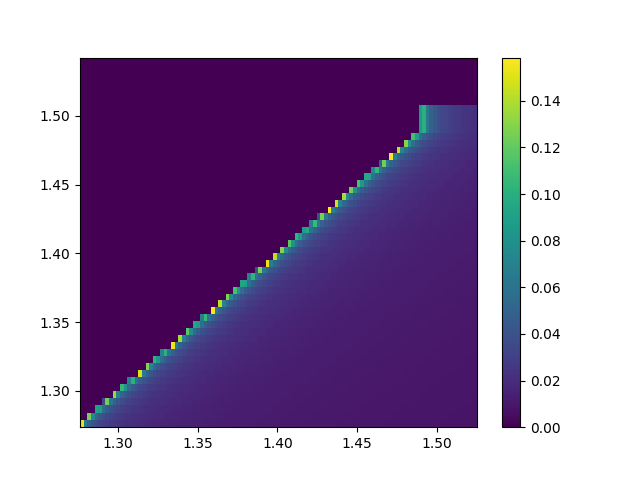

In [10]:
plt.figure()
plt.pcolormesh(RgridB, R[mask], dL)
plt.colorbar()
# plt.plot(RgridB, dL[100])

In [11]:
dL.shape, err.shape

((45, 109), (1, 178))

In [12]:
tind = 0

errZinds = np.where(np.isclose(err[tind], 0.))
T = dL / err[tind,mask,None] * scale
mean_d = data[tind,mask] / err[tind,mask]
### replace infs and NaNs
T[errZinds] = 0.
mean_d[errZinds] = 0.

In [13]:
W = np.ones(nGrid-1)
W

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1.])

In [14]:
### normally iterates over nfisher here, hence the f=0, this is the first iteration
f = 0

### multiply tridiagonal regularisation operator 
### by a diagonal weight matrix W
WD = np.copy(D)
### seems redundent, as W is all ones
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]

### transpose the band matrix
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]

In [15]:
np.isclose(WD, D).all(), np.isclose(D, WD).all()

(True, True)

In [16]:
DTW

array([[ 1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  0. ,  0. ],
       [-1. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. ,
        -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. ,
        -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. ,
        -2. , -2. , -2. , -2. , -2. , -2. ,

In [17]:
print(D[:,:5])
print('')
print(DTW[:,:5])

[[ 1.  1.  1.  1.  1.]
 [-1. -2. -2. -2. -2.]
 [ 1.  1.  1.  1.  1.]]

[[ 1.  1.  1.  1.  1.]
 [-1. -2. -2. -2. -2.]
 [ 1.  1.  1.  1.  1.]]


In [18]:
print(D[:,-5:])
print('')
print(DTW[:,-5:])

[[ 1.   1.   1.   1.   1. ]
 [-2.  -2.  -2.  -1.   0.1]
 [ 1.   1.   0.   0.   1. ]]

[[ 1.   1.   1.   0.   0. ]
 [-2.  -2.  -2.  -1.   0.1]
 [ 1.   1.   1.   1.   1. ]]


In [19]:
from scipy.interpolate import RegularGridInterpolator
from scipy.linalg import eigh, solve_banded

In [20]:
np.isclose(T[indLos,indSpace], T).all(), np.isclose(T, T[indLos,indSpace]).all()

(True, True)

In [21]:
# so if the nomenclature is the same in here as it is in the paper
# then the T is simlar to a geometry matrix

In [22]:
### (l, u), ab (shape is (3,459)), b (shape (459,185), after transpose), 
### the docstring example confuses me and doesn't seem
### to line up with my example

### solve Tikhonov regularization (optimised for speed)
H = solve_banded(
    (1, 1), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)

In [23]:
H.shape

(109, 45)

Some times you'll do a solve like this to avoid doing a direct inverse.<br>
So this is probably giving us some product with the inverse in (D^-1 T) to save us finding D^-1 directly. We use this in later steps

In [24]:
### so H is probably the same thing in here as it is in the paper too
#  probably gamma H is. So LL is the H later, LTL in the paper
### 
### also take a look at the Tikinhov wiki page and hte multivariate normal distribution wiki page

In [25]:
### fast method to calculate U, S, V = svd(H.T) of rectangular matrix
LL = np.dot(H.T, H)

### so it does the matrix multiplication of its transpose with itself

In [26]:
### L is a standard nomenclature for Cholesky Decomposition
### A = L LT
### this is to do with triangluar matrices and positive-definite matrices

In [27]:
H.T.shape, H.shape

((45, 109), (109, 45))

In [28]:
LL.shape

(45, 45)

In [29]:
### also from scipy
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)

### from scipy - 
### Solve a standrard or generalised eigenvalue problem for a 
### complex Hermitian or real symmetric matrix.

### S2 is w - selected eigenvalues, in ascending order, each 
###     repeated according to its multiplicity
### U is v - normalised eigenvector corresponding to the eigenvalue 
###     w[i] is the column v[:,i].

In [30]:
S2.shape, U.shape

((45,), (45, 45))

In [31]:
S2

array([0.00000000e+00, 9.06950923e-03, 1.15075606e-02, 1.29754968e-02,
       1.59962460e-02, 1.88206162e-02, 1.98858299e-02, 2.20660694e-02,
       2.55723837e-02, 2.74897080e-02, 3.24686961e-02, 3.71294536e-02,
       4.01370451e-02, 4.58191640e-02, 5.37722897e-02, 6.49132013e-02,
       7.45365904e-02, 9.25433917e-02, 1.07319451e-01, 1.37313805e-01,
       1.66999975e-01, 2.13241127e-01, 2.59759546e-01, 3.37751283e-01,
       4.27141700e-01, 5.51324864e-01, 7.04475635e-01, 9.84943621e-01,
       1.28466228e+00, 1.85898983e+00, 2.59506862e+00, 3.76171254e+00,
       5.33679567e+00, 8.45355427e+00, 1.40705313e+01, 2.21978222e+01,
       4.35486929e+01, 8.32344517e+01, 1.90914118e+02, 4.98085828e+02,
       1.51940495e+03, 6.11087943e+03, 3.18190256e+04, 3.23912490e+05,
       5.06066722e+07])

In [32]:
np.isclose(S2, np.maximum(S2, 1.))

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [33]:
### matrices with small eignevalues is basically making doing the 
### inverse problems difficult (not quite numerical issues, but it kind of leads to that)
### It can have really small values in reality, but it can lead to problems.
S2 = np.maximum(S2, 1.)
### check out what makes an invertible matrix in wiki

### a sanity check I can do is plot the eigenvalues (or max and min)
### 

In [34]:
mean_d[indLos].shape, U.shape, 

((45,), (45, 45))

In [35]:
###
mean_p = np.dot(mean_d[indLos], U)

### so I thnk this is matrix multiplication still

In [36]:
### the woodbury matrix identity


In [37]:
mean_d[indLos].shape

(45,)

In [38]:
mean_p.shape

(45,)

In [39]:
### generalised cross validation
### 

In [40]:
### guess for regularisation - estimate quantile of log(S^2)
g0 = np.interp(regGuess, Q, np.log(S2))

In [41]:
### if f == (nFisher - 1)
### but it doesn't, so not that branche
### else:

### filtering factor
w = 1. / (1. + np.exp(g0) / S2)
print(w)

[0.22259248 0.22259248 0.22259248 0.22259248 0.22259248 0.22259248
 0.22259248 0.22259248 0.22259248 0.22259248 0.22259248 0.22259248
 0.22259248 0.22259248 0.22259248 0.22259248 0.22259248 0.22259248
 0.22259248 0.22259248 0.22259248 0.22259248 0.22259248 0.22259248
 0.22259248 0.22259248 0.22259248 0.22259248 0.26891661 0.34737704
 0.4262888  0.51855454 0.60444082 0.70764318 0.80114413 0.86405337
 0.92575627 0.95972977 0.982035   0.99303695 0.99770666 0.9994288
 0.99989025 0.99998922 0.99999993]


In [42]:
### calcualte y without evaluatin v explicitely
Y = np.dot(H, np.dot(U / S2, w * mean_p))

### H is the output from solve_banded
### U is the second output from eigh
### S2 is the first output from eigh (but a minimum value of 1 imposed)
### w is a bunch of ones
### mean_p is the matrix multiplication of mean_d and U
###     mean_d is the data divided by the error

print(Y.shape)

### final inversion of mean solution , reconstruction
Y = solve_banded(
    (1,1), WD, Y, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)

### WD was a copy of the regularisation matrix
print(Y.shape)

(109,)
(109,)


In [43]:
### weight matrix for the next iteration
W = 1. / np.maximum(Y, 1e-10)**.5
print(W.shape)

(109,)


In [44]:
nFisher

4

In [45]:
### f = 1

WD = np.copy(D)
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]
H = solve_banded(
    (1, 1), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)
LL = np.dot(H.T, H)
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)
S2 = np.maximum(S2, 1)
mean_p = np.dot(mean_d[indLos], U)
g0 = np.interp(regGuess, Q, np.log(S2))
w = 1. / (1. + np.exp(g0) / S2)
Y = np.dot(H, np.dot(U / S2, w * mean_p))
Y = solve_banded(
    (1,1), WD, Y, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)
W = 1. / np.maximum(Y, 1e-10)**.5

In [46]:
### f = 2

WD = np.copy(D)
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]
H = solve_banded(
    (1, 1), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)
LL = np.dot(H.T, H)
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)
S2 = np.maximum(S2, 1)
mean_p = np.dot(mean_d[indLos], U)
g0 = np.interp(regGuess, Q, np.log(S2))
w = 1. / (1. + np.exp(g0) / S2)
Y = np.dot(H, np.dot(U / S2, w * mean_p))
Y = solve_banded(
    (1,1), WD, Y, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)
W = 1. / np.maximum(Y, 1e-10)**.5

In [47]:
### f=3 == (nFisher-1)

In [48]:
WD = np.copy(D)
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]
H = solve_banded(
    (1, 1), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)
LL = np.dot(H.T, H)
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)
S2 = np.maximum(S2, 1)
mean_p = np.dot(mean_d[indLos], U)
g0 = np.interp(regGuess, Q, np.log(S2))

In [49]:
### last step - find optimal regularisation
S = np.sqrt(S2)

In [50]:
def GCV(g, prod, S, U):
    ### generalized crossvalidation
    w = 1. / (1. + np.exp(g) / S**2)
    ndets = len(prod)
    return (np.sum((((w - 1) * prod))**2) + 1) / ndets / (1 - np.mean(w))**2

def FindMin(F, x0, dx0, prod, S, U, tol=0.01):
    ### stupid but robust minimum searching algorithm.
    fg = F(x0, prod, S, U)
    while abs(dx0) > tol:
        fg2 = F(x0 + dx0, prod, S, U)
        if fg2 < fg:
            fg = fg2
            x0 += dx0
            continue
        else:
            dx0 /= -2.
    return x0, np.log(fg2)

In [51]:
g0, log_fg2 = FindMin(GCV, g0, 1, mean_p, S, U.T) # slowest step
print(g0.shape)
print(log_fg2.shape)
print(g0, log_fg2)

()
()
6.2093606690844405 -0.8991368633074119


In [52]:
### avoid too small regularisation when min of GCV is not found
gmin = np.interp(regMin, Q, np.log(S2))
g0 = max(g0, gmin)

In [53]:
print(gmin, g0)

0.0 6.2093606690844405


In [54]:
### filtering factor
w = 1. / (1. + np.exp(g0) / S2)

In [55]:
### H was solve_banded
### U was the second output of eigh
### S was the sqrt of the first output of eigh

In [56]:
V = np.dot(H, U / S)
V = solve_banded(
    (1,1), WD, V, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)
print(V.shape)

(109, 45)


In [57]:
mean_d[indLos].shape, U.shape

((45,), (45, 45))

In [58]:
p = np.dot(mean_d[indLos], U)
print(p.shape)

(45,)


In [59]:
((w / S) * p).shape, V.T.shape

((45,), (45, 109))

In [60]:
### this is the result
Y = np.dot((w / S) * p, V.T) * scale
print(Y.shape)

(109,)


In [61]:
### this is the error of the result
yErr = np.sqrt(np.dot(V**2, (w / S)**2)) * scale

In [62]:
backprojection = fit = np.dot(p*w, U.T) * err[tind,mask]

/tmp/ipykernel_26190/293669263.py:1: RuntimeWarning: invalid value encountered in multiply
  backprojection = fit = np.dot(p*w, U.T) * err[tind,mask]


In [63]:
chi2 = np.sum((mean_d[indLos] - fit)**2) / len(fit)

In [64]:
gamma = np.interp(g0, np.log(S2), Q)

In [65]:
R[mask].shape, backprojection.shape

((45,), (45,))

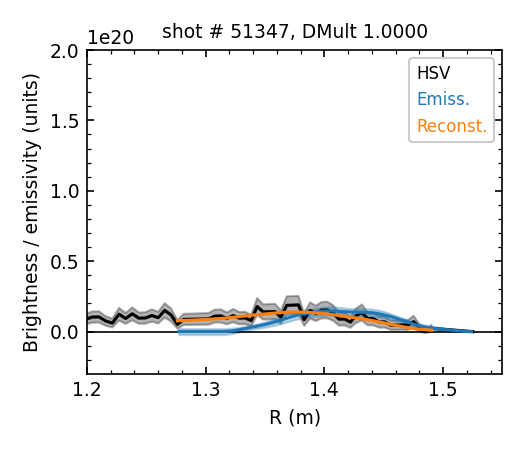

In [66]:
xlim = [1.2,1.55]
ylim = [-0.3e20,2e20]

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, data[tind], c='k', label='HSV')
ax.fill_between(
    R, data[tind]-err[tind], 
    data[tind]+err[tind], color='k', alpha=0.3
)

ax.plot(RgridB, Y, c='C0', label='Emiss.')
ax.fill_between(
    RgridB, Y-yErr, Y+yErr, color='C0', alpha=0.3
)

ax.plot(R[mask], backprojection, c='C1', label='Reconst.')

ax.set_xlim(xlim)
ax.plot(xlim, [0.,0.], '-k', lw=0.8, zorder=1)
ax.set_ylim(ylim)
ax.legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)

ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Brightness / emissivity (units)', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)

ax.set_title(f'shot # {shotn}, DMult {Dmult:.4f}', fontsize=9)

plt.tight_layout()

In [67]:
np.savez(
    f'/home/sthoma/tokamak_inversion_routines/Testing/TestingAlgorithm/{shotn}_testA.npy',
    R = R, 
    RgridB = RgridB, 
    y = Y, 
    yErr = yErr, 
    data = data[tind], 
    err = err[tind], 
    backprojection = backprojection, 
)